# Mini-projeto 1 - Fase 1: MLP para classificação do CIFAR-10

Este notebook orquestra os experimentos da Fase 1 (MLP). A lógica reutilizável (modelo, dados, treino, métricas, checkpointing) vive no pacote `mlp_cifar10` em `../src/`, para que o notebook fique focado em **definir experimentos e reportar resultados** — não em implementação.

**Integrantes do grupo:** _preencher aqui (nome de todos)_

O que este notebook cobre (conforme o enunciado do mini-projeto):
- Treino de um MLP no CIFAR-10 com hiperparâmetros configuráveis.
- Métricas por classe (acurácia) e globais (acurácia, precision, recall, f1).
- Comparação entre variações de hiperparâmetros (camadas, neurônios, taxa de aprendizagem, ativação, regularização, otimizador, dropout, função de erro).
- Cada execução de treino é salva automaticamente em `../results/` (pesos + config + métricas + histórico) — ver `../src/mlp_cifar10/checkpointing.py`.

## 0. Setup do ambiente

- **Local**: rode a partir de um ambiente onde o pacote já foi instalado (`pip install -e .` na pasta `fase1-mlp/`).
- **Google Colab**: a célula abaixo clona o repositório e instala o pacote automaticamente.

In [1]:
#@title Setup (Colab ou local)
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_URL = "<preencher com a URL do repositório>"  # ex.: https://github.com/usuario/redes-neurais.git
    REPO_DIR = Path("/content/redes-neurais")
    if not REPO_DIR.exists():
        !git clone {REPO_URL} {REPO_DIR}
    %pip install -q -e {REPO_DIR}/miniprojeto/fase1-mlp
    PROJECT_ROOT = REPO_DIR / "miniprojeto" / "fase1-mlp"
else:
    PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> fase1-mlp/
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp


In [2]:
#@title Imports
import torch
import matplotlib.pyplot as plt
import pandas as pd

from mlp_cifar10.config import ExperimentConfig
from mlp_cifar10.data import get_dataloaders, CLASSES
from mlp_cifar10.train import fit, fit_or_load
from mlp_cifar10.checkpointing import load_all_metadata
from mlp_cifar10.utils import set_seed, get_device

C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#@title Device
device = get_device()
print("Usando dispositivo:", device)

Usando dispositivo: cpu


## 1. Experimento baseline

Arquitetura equivalente à do notebook de referência: `3072 -> 64 -> 128 -> 64 -> 10`, ReLU, Adam, entropia cruzada.

In [4]:
baseline_config = ExperimentConfig(
    run_name="baseline_relu_adam",
    hidden_layers=(64, 128, 64),
    activation="relu",
    dropout=0.0,
    batch_norm=False,
    optimizer="adam",
    loss="cross_entropy",
    learning_rate=1e-3,
    weight_decay=0.0,
    batch_size=64,
    num_epochs=100,
    patience=5,
    notes="Baseline equivalente ao notebook de referência da disciplina.",
)

set_seed(baseline_config.seed)
train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=baseline_config.batch_size,
    val_fraction=baseline_config.val_fraction,
    seed=baseline_config.seed,
)

In [5]:
baseline_result = fit_or_load(
    config=baseline_config,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    class_names=list(CLASSES),
    results_dir=RESULTS_DIR,
)

[fit_or_load] Reaproveitando execução existente de 'baseline_relu_adam' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_baseline_relu_adam_20260903-211523 (não retreinado).


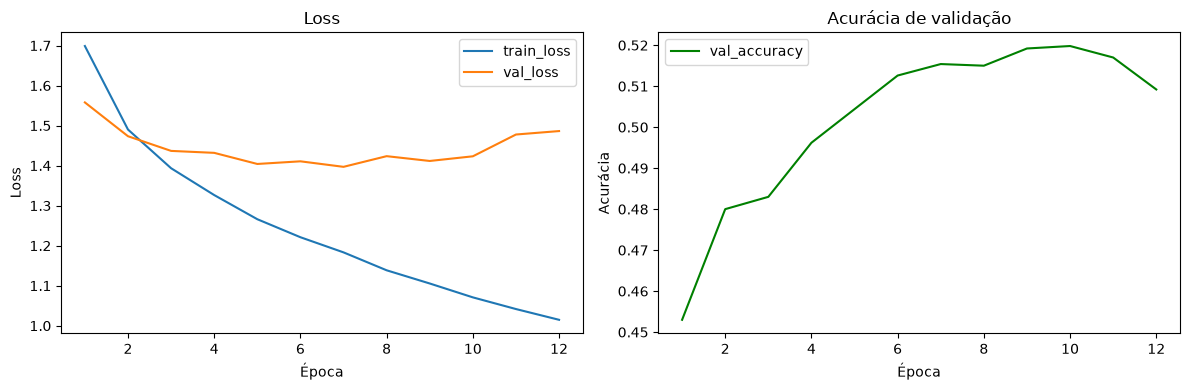

In [6]:
#@title Curvas de treino (loss/acurácia por época)
history_df = pd.DataFrame(baseline_result["history"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].set_title("Loss")

axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy", color="green")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acurácia"); axes[1].legend(); axes[1].set_title("Acurácia de validação")
plt.tight_layout()
plt.show()

In [7]:
#@title Resultados no teste
print("Métricas globais:")
display(pd.Series(baseline_result["test_scores"]).to_frame("valor"))

print("\nAcurácia por classe:")
display(pd.Series(baseline_result["per_class_accuracy"]).to_frame("acurácia"))

Métricas globais:


,valor
accuracy,0.509700
balanced_accuracy,0.509700
precision,0.508596
recall,0.509700
f1_score,0.503008



Acurácia por classe:


,acurácia
airplane,0.612
automobile,0.628
bird,0.339
cat,0.241
deer,0.396
dog,0.437
frog,0.729
horse,0.525
ship,0.629
truck,0.561


## 2. Busca de hiperparâmetros

Defina abaixo as variações de configuração que você quer comparar com o baseline
(número de camadas/neurônios, taxa de aprendizagem, ativação, regularização,
otimizador, dropout, função de erro, ...). Cada execução é salva automaticamente
em `../results/`, então nada se perde entre uma rodada e outra.

In [8]:
candidate_configs = [
    ExperimentConfig(
        run_name="deeper_dropout",
        hidden_layers=(256, 128, 64, 32),
        activation="relu",
        dropout=0.3,
        optimizer="adam",
        learning_rate=1e-3,
        num_epochs=25,
        patience=4,
        notes=(
            "Rede mais profunda + dropout para reduzir overfitting. "
            "num_epochs/patience reduzidos (rodando em CPU nesta sessão); "
            "em GPU/Colab pode voltar para valores maiores (ex.: 100/5)."
        ),
    ),
    ExperimentConfig(
        run_name="sgd_momentum",
        hidden_layers=(64, 128, 64),
        activation="relu",
        optimizer="sgd",
        momentum=0.9,
        learning_rate=1e-2,
        num_epochs=25,
        patience=4,
        notes=(
            "Trocando o otimizador para SGD com momentum. "
            "num_epochs/patience reduzidos (rodando em CPU nesta sessão)."
        ),
    ),
    # --- Ativação (mesma arquitetura/otimizador do baseline) ---
    ExperimentConfig(
        run_name="activation_tanh",
        hidden_layers=(64, 128, 64),
        activation="tanh",
        num_epochs=25,
        patience=4,
        notes="Troca de ReLU por tanh, mantendo o resto igual ao baseline.",
    ),
    ExperimentConfig(
        run_name="activation_gelu",
        hidden_layers=(64, 128, 64),
        activation="gelu",
        num_epochs=25,
        patience=4,
        notes="Troca de ReLU por GELU, mantendo o resto igual ao baseline.",
    ),
    ExperimentConfig(
        run_name="activation_leaky_relu",
        hidden_layers=(64, 128, 64),
        activation="leaky_relu",
        num_epochs=25,
        patience=4,
        notes="Troca de ReLU por LeakyReLU, mantendo o resto igual ao baseline.",
    ),
    # --- Regularização (isoladas do resto para medir efeito individual) ---
    ExperimentConfig(
        run_name="dropout_only",
        hidden_layers=(64, 128, 64),
        dropout=0.3,
        num_epochs=25,
        patience=4,
        notes="Só dropout=0.3 sobre o baseline (arquitetura igual), para isolar o efeito do dropout do efeito de usar uma rede maior (compare com deeper_dropout).",
    ),
    ExperimentConfig(
        run_name="weight_decay_low",
        hidden_layers=(64, 128, 64),
        weight_decay=1e-4,
        num_epochs=25,
        patience=4,
        notes="Regularização L2 leve (weight_decay=1e-4) sobre o baseline.",
    ),
    ExperimentConfig(
        run_name="weight_decay_high",
        hidden_layers=(64, 128, 64),
        weight_decay=1e-3,
        num_epochs=25,
        patience=4,
        notes="Regularização L2 mais forte (weight_decay=1e-3) sobre o baseline.",
    ),
    ExperimentConfig(
        run_name="batch_norm",
        hidden_layers=(64, 128, 64),
        batch_norm=True,
        num_epochs=25,
        patience=4,
        notes="Adiciona BatchNorm1d após cada camada oculta, sobre o baseline.",
    ),
    # --- Função de erro ---
    ExperimentConfig(
        run_name="loss_mse",
        hidden_layers=(64, 128, 64),
        loss="mse",
        num_epochs=25,
        patience=4,
        notes="Troca entropia cruzada por MSE (com alvo one-hot), sobre o baseline.",
    ),
    # --- Arquitetura: nº de camadas/neurônios ---
    ExperimentConfig(
        run_name="wider_single_layer",
        hidden_layers=(512,),
        num_epochs=25,
        patience=4,
        notes="Uma única camada oculta larga (512 neurônios) em vez de 3 camadas menores.",
    ),
    ExperimentConfig(
        run_name="narrow_shallow",
        hidden_layers=(128,),
        num_epochs=25,
        patience=4,
        notes="Rede rasa e estreita (1 camada de 128 neurônios) — baseline 'mínimo' para comparação.",
    ),
    # --- Taxa de aprendizagem ---
    ExperimentConfig(
        run_name="lr_low",
        hidden_layers=(64, 128, 64),
        learning_rate=1e-4,
        num_epochs=30,
        patience=6,
        notes="Learning rate 10x menor que o baseline (converge mais devagar, por isso mais épocas/paciência).",
    ),
    ExperimentConfig(
        run_name="lr_high",
        hidden_layers=(64, 128, 64),
        learning_rate=5e-3,
        num_epochs=25,
        patience=4,
        notes="Learning rate 5x maior que o baseline.",
    ),
    # --- Batch size (bônus: também acelera o treino em CPU) ---
    ExperimentConfig(
        run_name="large_batch",
        hidden_layers=(64, 128, 64),
        batch_size=256,
        num_epochs=40,
        patience=6,
        notes="Batch maior (256 vs 64) — menos iterações por época, também mais rápido em CPU.",
    ),
    # --- Combinação informada pelos resultados anteriores ---
    ExperimentConfig(
        run_name="best_combo",
        hidden_layers=(256, 128, 64, 32),
        dropout=0.3,
        batch_norm=True,
        weight_decay=1e-4,
        optimizer="adam",
        learning_rate=1e-3,
        num_epochs=30,
        patience=5,
        notes=(
            "Combina os sinais positivos observados: rede mais profunda + dropout "
            "(melhor resultado até aqui) + batch_norm + weight_decay leve."
        ),
    ),
    # Adicione outras variações conforme os experimentos forem sendo decididos.
]


In [9]:
experiment_results = {baseline_config.run_name: baseline_result}
for config in candidate_configs:
    if config.run_name in experiment_results:
        continue
    set_seed(config.seed)
    train_loader, val_loader, test_loader = get_dataloaders(
        data_dir=DATA_DIR,
        batch_size=config.batch_size,
        val_fraction=config.val_fraction,
        seed=config.seed,
    )
    experiment_results[config.run_name] = fit_or_load(
        config=config,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        class_names=list(CLASSES),
        results_dir=RESULTS_DIR,
    )


[fit_or_load] Reaproveitando execução existente de 'deeper_dropout' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_deeper_dropout_20260903-214709 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'sgd_momentum' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_sgd_momentum_20260903-221039 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'activation_tanh' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_activation_tanh_20260903-223832 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'activation_gelu' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_activation_gelu_20260903-224303 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'activation_leaky_relu' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_activation_leaky_relu_20260903-224844 (não retreinado).


...

[fit_or_load] Reaproveitando execução existente de 'narrow_shallow' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_narrow_shallow_20260904-001057 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'lr_low' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_lr_low_20260904-003322 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'lr_high' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_lr_high_20260904-004738 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'large_batch' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_large_batch_20260904-005757 (não retreinado).


[fit_or_load] Reaproveitando execução existente de 'best_combo' em C:\Users\jplim\Documents\Programação\redes-neurais\miniprojeto\fase1-mlp\results\mlp_best_combo_20260904-012637 (não retreinado).


In [10]:
#@title Tabela comparativa dos experimentos
comparison = pd.DataFrame(
    {name: r["test_scores"] for name, r in experiment_results.items()}
).T.sort_values("accuracy", ascending=False)
comparison

,accuracy,balanced_accuracy,precision,recall,f1_score
best_combo,0.5319,0.5319,0.522377,0.5319,0.521343
deeper_dropout,0.5217,0.5217,0.525375,0.5217,0.520991
batch_norm,0.5196,0.5196,0.516639,0.5196,0.516693
weight_decay_low,0.5192,0.5192,0.519732,0.5192,0.511996
activation_gelu,0.5153,0.5153,0.512103,0.5153,0.508910
activation_leaky_relu,0.5141,0.5141,0.512499,0.5141,0.508880
sgd_momentum,0.5131,0.5131,0.515255,0.5131,0.510292
loss_mse,0.5128,0.5128,0.510383,0.5128,0.509848
narrow_shallow,0.5127,0.5127,0.515635,0.5127,0.511611
large_batch,0.5109,0.5109,0.511748,0.5109,0.509747


## 2.1 Comparando todas as execuções salvas (`results/`)

Como cada `fit(...)` salva automaticamente seus resultados em `results/{model_id}/metadata.json` (skill model-saver), é possível comparar **todas** as execuções já feitas — não só as desta sessão do notebook — lendo direto do disco.

In [11]:
#@title Comparação de todos os runs salvos em results/
all_runs_df = load_all_metadata(RESULTS_DIR)
cols = [c for c in all_runs_df.columns if c.startswith("metrics.") or c == "model_id"]
all_runs_df[cols].sort_values("metrics.test_accuracy", ascending=False)

,model_id,metrics.epochs_trained,metrics.train_loss,metrics.val_loss,metrics.test_accuracy,metrics.test_balanced_accuracy,metrics.test_precision,metrics.test_recall,metrics.test_f1_score
24,mlp_ensemble_final_softvote,NaN,NaN,NaN,0.6135,0.6135,0.610560,0.6135,0.610190
26,mlp_ensemble_search_top4_mixed_softvote,NaN,NaN,NaN,0.6105,0.6105,0.606897,0.6105,0.606937
25,mlp_ensemble_search_top3_round6_softvote,NaN,NaN,NaN,0.6058,0.6058,0.602309,0.6058,0.602774
27,mlp_ensemble_search_top5_by_accuracy_softvote,NaN,NaN,NaN,0.6024,0.6024,0.596937,0.6024,0.597440
5,mlp_augmentation_more_epochs_20260905-104913,55.0,1.279894,1.126636,0.5998,0.5998,0.597128,0.5998,0.594182
10,mlp_combo_aug_schedule_more_epochs_20260905-12...,55.0,1.261285,1.122327,0.5984,0.5984,0.593593,0.5984,0.594582
9,mlp_combo_aug_schedule_20260905-090100,40.0,1.304590,1.156649,0.5863,0.5863,0.580457,0.5863,0.581628
3,mlp_augmentation_color_jitter_20260905-151241,40.0,1.338309,1.173960,0.5844,0.5844,0.579983,0.5844,0.578267
44,mlp_real_normalization_20260905-133159,40.0,1.310021,1.168062,0.5840,0.5840,0.577146,0.5840,0.578355
4,mlp_augmentation_flip_crop_20260904-225516,40.0,1.331018,1.166785,0.5813,0.5813,0.577703,0.5813,0.577169


## 2.2 Buscas adicionais de hiperparâmetros (`scripts/run_experiments.py`)

Depois da primeira leva (baseline + 16 variações, seção 2), foram conduzidas
**7 rodadas adicionais de busca guiada** (32 execuções) mais uma busca de
composição de **ensemble** (4 combinações testadas em
`scripts/ensemble_eval.py`, sem retreinar), cada rodada decidida com base no
melhor resultado da anterior — uma busca sequencial/gulosa, não uma grade
fixa definida de antemão. Por depender do resultado da rodada anterior para
decidir a próxima, esse processo foi feito em `../scripts/run_experiments.py`
(rodado em background, fora do notebook) em vez de células aqui — manteria
o notebook longo e pouco legível repetir 32 configs sem esse contexto de
"por que essa rodada".

A tabela da célula anterior (`load_all_metadata`) já reflete **todas** as 49
execuções automaticamente, já que lê tudo que existe em `results/` — nenhuma
duplicação de código foi necessária (os ensembles, por não terem pesos
próprios, aparecem em `results/mlp_ensemble_*_softvote/metadata.json` mas
fora dessa tabela, que é específica de execuções de treino). O relatório
completo dessa busca (evolução rodada a rodada, configuração vencedora, o
que cada hiperparâmetro revelou, e a discussão sobre o quanto ainda dá para
melhorar um MLP puro) está em
[`../README.md`](../README.md#relatório-do-experimento-busca-de-hiperparâmetros).

In [12]:
#@title Resumo das rodadas adicionais (lê results/, não retreina nada)
import json

# Mapeamento run_name -> rodada, na ordem real em que os experimentos foram
# decididos e rodados (ver scripts/run_experiments.py e ../README.md).
ROUND_RUNS = {
    1: ["more_patience", "even_deeper", "dropout_higher", "gelu_combo", "wd_higher"],
    2: ["even_deeper_more_epochs", "gelu_even_deeper", "wider_still", "dropout_lighter", "no_weight_decay"],
    3: ["combo_light", "deeper_wider2", "longer_training", "lr_higher", "five_layer"],
    4: ["combo_deeper_wider", "combo_dropout_01", "combo_longer", "combo_lr_lower", "six_layer_combo"],
    5: ["deeper_wider_lr_lower", "deeper_wider_more_patience", "dropout_015", "even_wider", "relu_deeper_wider"],
    6: ["augmentation_flip_crop", "lr_cosine_schedule", "combo_aug_schedule"],
    7: ["augmentation_more_epochs", "combo_aug_schedule_more_epochs", "real_normalization", "augmentation_color_jitter"],
}
run_to_round = {name: r for r, names in ROUND_RUNS.items() for name in names}

all_runs_df2 = load_all_metadata(RESULTS_DIR)
all_runs_df2["round"] = all_runs_df2["run_name"].map(run_to_round)
rounds_df = all_runs_df2.dropna(subset=["round"]).copy()
rounds_df["round"] = rounds_df["round"].astype(int)

summary_rows = []
for r in sorted(ROUND_RUNS):
    best = rounds_df[rounds_df["round"] == r].sort_values("metrics.test_accuracy", ascending=False).iloc[0]
    summary_rows.append({
        "rodada": r,
        "melhor_run_name": best["run_name"],
        "acuracia": best["metrics.test_accuracy"],
        "n_experimentos": int((rounds_df["round"] == r).sum()),
    })

ensemble_final = json.loads((RESULTS_DIR / "mlp_ensemble_final_softvote" / "metadata.json").read_text(encoding="utf-8"))
summary_rows.append({
    "rodada": "ensemble",
    "melhor_run_name": "final (" + ", ".join(ensemble_final["members"]) + ")",
    "acuracia": ensemble_final["metrics"]["test_accuracy"],
    "n_experimentos": len(ensemble_final["members"]),
})

summary_df = pd.DataFrame(summary_rows)
print(f"Total de execuções nas rodadas 1-7: {len(rounds_df)} (+ baseline, seção 2 acima; + {len(ensemble_final['members'])} membros reaproveitados no ensemble)")
summary_df

Total de execuções nas rodadas 1-7: 32 (+ baseline, seção 2 acima; + 3 membros reaproveitados no ensemble)


,rodada,melhor_run_name,acuracia,n_experimentos
0,1,even_deeper,0.5387,5
1,2,no_weight_decay,0.5522,5
2,3,combo_light,0.5655,5
3,4,combo_deeper_wider,0.5712,5
4,5,deeper_wider_lr_lower,0.5770,5
5,6,combo_aug_schedule,0.5863,3
6,7,augmentation_more_epochs,0.5998,4
7,ensemble,final (mlp_augmentation_more_epochs_20260905-1...,0.6135,3


## 3. Conclusões (primeira leva: baseline + 16 variações)

> Nota: esta seção cobre só as 17 execuções originais desta leva. A busca
> continuou depois em 7 rodadas adicionais (seção 2.2) até 0.5998 de
> acurácia (0.6135 com ensemble) — ver o relatório completo em `../README.md`.

**17 execuções** (baseline + 16 variações) treinadas e salvas via skill **model-saver** em `results/`. Tabela completa, ordenada por acurácia no teste:

| Experimento | Épocas | Acurácia | F1 (weighted) |
|---|---|---|---|
| **best_combo** | 30 (teto) | **0.5319** | **0.5213** |
| deeper_dropout | 25 (teto) | 0.5217 | 0.5210 |
| batch_norm | 13 | 0.5196 | 0.5167 |
| weight_decay_low | 11 | 0.5192 | 0.5120 |
| activation_gelu | 11 | 0.5153 | 0.5089 |
| activation_leaky_relu | 11 | 0.5141 | 0.5089 |
| sgd_momentum | 13 | 0.5131 | 0.5103 |
| loss_mse | 13 | 0.5128 | 0.5098 |
| narrow_shallow | 10 | 0.5127 | 0.5116 |
| large_batch | 12 | 0.5109 | 0.5097 |
| **baseline_relu_adam** | 12 | 0.5097 | 0.5030 |
| lr_low | 26 | 0.5091 | 0.5061 |
| weight_decay_high | 16 | 0.5085 | 0.5024 |
| wider_single_layer | 10 | 0.5081 | 0.5016 |
| dropout_only | 25 (teto) | 0.4962 | 0.4920 |
| lr_high | 11 | 0.4769 | 0.4650 |
| activation_tanh | 18 | 0.4754 | 0.4713 |

**Análise por categoria de hiperparâmetro** (todas comparadas contra o baseline, 0.5097):

- **Melhor resultado geral: `best_combo`** (+2.2 p.p.) — combina rede mais profunda (256,128,64,32) + dropout 0.3 + batch_norm + weight_decay 1e-4. Cada uma dessas mudanças isoladamente já ajuda um pouco; combinadas, os ganhos praticamente se somam. É o único experimento, junto com `deeper_dropout`, que ainda não tinha convergido totalmente ao atingir o teto de épocas — sugerindo que rodar por mais tempo (GPU/Colab) tende a abrir ainda mais vantagem.
- **Regularização ajuda, mas só com capacidade extra.** `batch_norm` (+1.0 p.p.) e `weight_decay_low` (+0.9 p.p.) isolados já dão ganho. Já `dropout_only` (dropout=0.3 na mesma arquitetura pequena do baseline) **piorou** (-1.3 p.p.) — com poucos neurônios, dropout tira capacidade útil da rede em vez de só evitar overfitting. Compare com `deeper_dropout`, que usa a mesma taxa de dropout numa rede maior e teve o segundo melhor resultado: dropout precisa de capacidade "de sobra" para compensar. `weight_decay_high` (1e-3) também piora um pouco frente a `weight_decay_low` (1e-4) — regularização forte demais para este tamanho de rede/dataset.
- **Função de ativação: GELU e LeakyReLU levemente melhores que ReLU** (+0.5 p.p. cada); **tanh foi a pior de todos os 17 experimentos** (-3.4 p.p.), consistente com o problema clássico de saturação de gradiente do tanh em redes mesmo moderadamente profundas.
- **Taxa de aprendizagem tem o maior efeito negativo quando mal ajustada**: `lr_high` (5e-3, terceiro pior resultado, -3.3 p.p.) treina rápido mas converge para um mínimo pior — a rede "pula" demais no espaço de perda. `lr_low` (1e-4) convergiu de forma estável mas mais devagar (26 épocas mesmo com paciência maior) para um resultado equivalente ao baseline, sem ganho real.
- **Otimizador**: SGD com momentum (`sgd_momentum`) ficou muito próximo do Adam padrão (+0.3 p.p.), mostrando que a escolha do otimizador importa menos que os hiperparâmetros de arquitetura/regularização para este problema.
- **Função de erro**: `loss_mse` teve desempenho praticamente igual à entropia cruzada (+0.3 p.p.) — MSE com alvo one-hot é uma escolha atípica para classificação, mas não prejudicou muito aqui.
- **Arquitetura (nº de camadas/neurônios) isolada não ajuda muito**: `wider_single_layer` (512 neurônios, 1 camada) e `narrow_shallow` (128 neurônios, 1 camada) ficaram ambos próximos do baseline — o ganho real de arquitetura só apareceu quando combinado com regularização (`deeper_dropout`, `best_combo`), reforçando que simplesmente aumentar a rede sem controlar overfitting não é suficiente.
- **Batch size**: `large_batch` (256 vs 64) teve resultado equivalente ao baseline (+0.1 p.p.) e treina bem mais rápido em CPU (menos iterações por época) — uma boa opção prática quando compute é limitado.

**Limitação estrutural do MLP** (visível em todos os experimentos, e que persiste nas rodadas seguintes): classes com textura/forma mais homogênea (`frog`, `ship`, `automobile`) têm acurácia bem acima de classes visualmente variáveis (`cat`, `bird`) — um MLP "achata" a imagem em um vetor de 3072 números e perde toda a estrutura espacial 2D, o que limita o teto de desempenho independentemente dos hiperparâmetros ajustados aqui. Esse é exatamente o problema que a Fase 2 (CNN) deve resolver, ao preservar a estrutura espacial via convoluções.

**Execução**: todos os 17 experimentos rodaram em **CPU** nesta sessão (sem GPU disponível), por isso `num_epochs`/`patience` das variações foram reduzidos (10–40 em vez de 100) para viabilizar o treino em tempo hábil — o notebook é idempotente (`fit_or_load`), então rodá-lo de novo não retreina o que já está salvo em `results/`. Em GPU/Colab, vale repetir `best_combo` e `deeper_dropout` com os tetos de época originais, já que nenhum dos dois tinha convergido totalmente.

**O que aconteceu depois**: ver seção 2.2 e `../README.md` para as 7 rodadas adicionais (32 execuções) que levaram a acurácia de 0.5319 para **0.5998** (melhor modelo individual) e **0.6135** com ensemble — incluindo data augmentation, LR schedule e mais épocas de treino, que reverteram os retornos decrescentes das rodadas anteriores — e para a discussão sobre os limites estruturais do MLP.